In [ ]:
import numpy as np
import pandas as pd

from sklearn.datasets import make_blobs
from scipy.stats import multivariate_normal

import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
import math
from collections import Counter

def KNN(points, p, k=3):
    distances = []
    for group in points:
        for feature in points[group]:
            euclidean_distance = math.sqrt((feature[0] - p[0]) ** 2 + (feature[1] - p[1]) ** 2)
            distances.append((euclidean_distance, group))

    distances = sorted(distances)[:k]
    nearest_neighbors = [d[1] for d in distances]
    most_common = Counter(nearest_neighbors).most_common(1)

    return most_common[0][0]

# Rest of your code


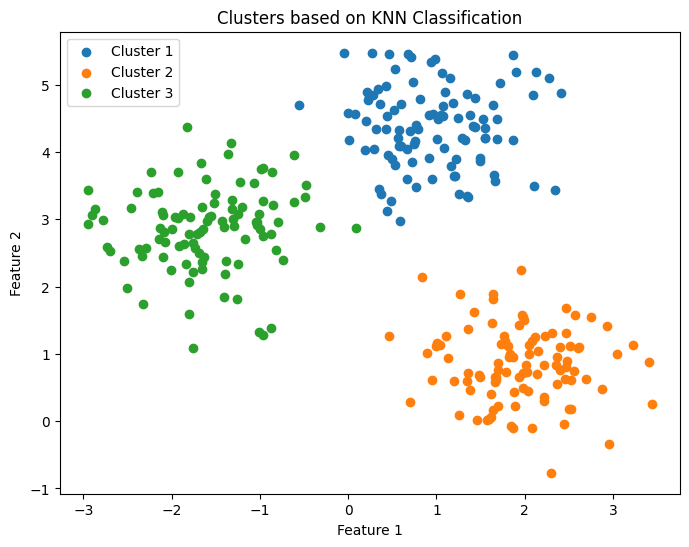

In [ ]:


# Tạo dataset make_blobs với 3 clusters
X, y = make_blobs(n_samples=300, centers=3, random_state=0, cluster_std=0.6)

# Dictionary để lưu trữ dữ liệu của từng cluster
points = {0: [], 1: [], 2: []}

for i, label in enumerate(y):
    points[label].append(X[i])

# Hàm classifyAPoint đã được định nghĩa trước đó

# Tính toán phân loại cho tất cả điểm trong dataset
classified_labels = []
for data_point in X:
    classification = KNN(points, data_point, k=3)
    classified_labels.append(classification)

# Chuyển classified_labels thành mảng NumPy
classified_labels = np.array(classified_labels)

# Vẽ biểu đồ các cluster dựa trên phân loại của KNN
plt.figure(figsize=(8, 6))
for i in range(3):
    cluster_points = X[classified_labels == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'Cluster {i + 1}')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Clusters based on KNN Classification')
plt.legend()
plt.show()
